In [5]:
#impoting the packages

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib import pyplot as plt
%matplotlib inline 
import seaborn as sns
import scipy.stats as stats  #for the statistical tests

In [6]:
#get the database
input_path = "E:\\new_python\\data\\Insurance Claims Case Study//"

In [9]:
file_name1 ="claims.csv"
file_name2 = "cust_demographics.csv"

In [11]:
claims= pd.read_csv(input_path+file_name1)

In [13]:
demog=pd.read_csv(input_path+file_name2)

In [15]:
# Dimensions of data
claims.shape

(1100, 10)

In [17]:
claims.isnull().sum()

claim_id                0
customer_id             0
incident_cause          0
claim_date              0
claim_area              0
police_report           0
claim_type              0
claim_amount           65
total_policy_claims    10
fraudulent              0
dtype: int64

In [19]:
claims.head()

,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent
0,54004764,21868593,Driver error,11/27/2017,Auto,No,Material only,$2980,1.0,No
1,33985796,75740424,Crime,10/03/2018,Home,Unknown,Material only,$2980,3.0,No
2,53522022,30308357,Other driver error,02/02/2018,Auto,No,Material only,$3369.5,1.0,Yes
3,13015401,47830476,Natural causes,06/17/2018,Auto,No,Material only,$1680,1.0,No
4,22890252,19269962,Crime,01/13/2018,Auto,No,Material only,$2680,1.0,No


In [21]:
demog.shape

(1085, 6)

In [23]:
demog.isnull().sum()

CUST_ID        0
gender         0
DateOfBirth    0
State          0
Contact        0
Segment        0
dtype: int64

In [25]:
demog.head()

,CUST_ID,gender,DateOfBirth,State,Contact,Segment
0,21868593,Female,12-Jan-79,VT,789-916-8172,Platinum
1,75740424,Female,13-Jan-70,ME,265-543-1264,Silver
2,30308357,Female,11-Mar-84,TN,798-631-4758,Silver
3,47830476,Female,01-May-86,MA,413-187-7945,Silver
4,19269962,Male,13-May-77,NV,956-871-8691,Gold


# 1 Import claims_data.csv and cust_data.csv which is provided to you and combine the two datasets appropriately to create a 360-degree view ofthe data.

In [28]:
def_df = pd.merge(right= claims, left= demog,
                  right_on= ["customer_id"], left_on= ["CUST_ID"], how= "outer")

In [30]:
def_df.drop(columns=["customer_id"], inplace = True)

In [32]:
def_df.head()

,CUST_ID,gender,DateOfBirth,State,Contact,Segment,claim_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent
0,154557.0,Female,23-May-78,DE,962-879-1238,Platinum,69348631.0,Driver error,04/10/2018,Auto,No,Injury only,NaN,1.0,Yes
1,263204.0,Male,20-Dec-72,TX,173-892-6314,Silver,40953049.0,Other causes,04/04/2018,Auto,No,Material and injury,$39192,1.0,Yes
2,287476.0,Male,28-Jul-88,FL,364-598-1549,Silver,45780237.0,Natural causes,10/17/2017,Auto,Unknown,Material only,$1621.5,2.0,Yes
3,441097.0,Male,19-Aug-71,CA,187-348-8375,Gold,89833962.0,Other causes,03/21/2018,Auto,Yes,Material and injury,$37040,1.0,No
4,524545.0,Female,10-Aug-80,NC,798-862-5398,Gold,35782742.0,Other driver error,07/27/2018,Auto,No,Injury only,$35250,3.0,No


In [34]:
def_df.shape

(1107, 15)

In [36]:
def_df.head()

,CUST_ID,gender,DateOfBirth,State,Contact,Segment,claim_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent
0,154557.0,Female,23-May-78,DE,962-879-1238,Platinum,69348631.0,Driver error,04/10/2018,Auto,No,Injury only,NaN,1.0,Yes
1,263204.0,Male,20-Dec-72,TX,173-892-6314,Silver,40953049.0,Other causes,04/04/2018,Auto,No,Material and injury,$39192,1.0,Yes
2,287476.0,Male,28-Jul-88,FL,364-598-1549,Silver,45780237.0,Natural causes,10/17/2017,Auto,Unknown,Material only,$1621.5,2.0,Yes
3,441097.0,Male,19-Aug-71,CA,187-348-8375,Gold,89833962.0,Other causes,03/21/2018,Auto,Yes,Material and injury,$37040,1.0,No
4,524545.0,Female,10-Aug-80,NC,798-862-5398,Gold,35782742.0,Other driver error,07/27/2018,Auto,No,Injury only,$35250,3.0,No


In [38]:
# Data types and Non - Null Count
def_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1107 entries, 0 to 1106
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CUST_ID              1092 non-null   float64
 1   gender               1092 non-null   object 
 2   DateOfBirth          1092 non-null   object 
 3   State                1092 non-null   object 
 4   Contact              1092 non-null   object 
 5   Segment              1092 non-null   object 
 6   claim_id             1100 non-null   float64
 7   incident_cause       1100 non-null   object 
 8   claim_date           1100 non-null   object 
 9   claim_area           1100 non-null   object 
 10  police_report        1100 non-null   object 
 11  claim_type           1100 non-null   object 
 12  claim_amount         1035 non-null   object 
 13  total_policy_claims  1090 non-null   float64
 14  fraudulent           1100 non-null   object 
dtypes: float64(3), object(12)
memory usage

In [40]:
def_df.isnull().sum()

CUST_ID                15
gender                 15
DateOfBirth            15
State                  15
Contact                15
Segment                15
claim_id                7
incident_cause          7
claim_date              7
claim_area              7
police_report           7
claim_type              7
claim_amount           72
total_policy_claims    17
fraudulent              7
dtype: int64

# 2Perform a data audit for the datatypes and find out if there are any mismatch within the current datatypes of the columns and their business significance.(for -DateOfBirth, claim_date )

In [43]:
#pd.to_datetime(tbl_ord['ORD_DTE'])
def_df["DateOfBirth"] = pd.to_datetime(def_df["DateOfBirth"],format= "%d-%b-%y")

In [45]:
def_df["claim_date"] = pd.to_datetime(def_df["claim_date"],format= "%m/%d/%Y")

In [47]:
def_df["Contact"] = def_df["Contact"].astype(str)

In [49]:
# Now replace the hyphen and convert to numeric
def_df["Contact"] = def_df["Contact"].str.replace("-", "")
def_df["Contact"] = pd.to_numeric(def_df["Contact"], errors='coerce')

In [51]:
def_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1107 entries, 0 to 1106
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   CUST_ID              1092 non-null   float64       
 1   gender               1092 non-null   object        
 2   DateOfBirth          1092 non-null   datetime64[ns]
 3   State                1092 non-null   object        
 4   Contact              1092 non-null   float64       
 5   Segment              1092 non-null   object        
 6   claim_id             1100 non-null   float64       
 7   incident_cause       1100 non-null   object        
 8   claim_date           1100 non-null   datetime64[ns]
 9   claim_area           1100 non-null   object        
 10  police_report        1100 non-null   object        
 11  claim_type           1100 non-null   object        
 12  claim_amount         1035 non-null   object        
 13  total_policy_claims  1090 non-nul

# 3Convert the column claim_amount to numeric. Use the appropriate modules/attributes to remove the $ sign.

In [54]:
def_df["claim_amount"] = pd.to_numeric(def_df["claim_amount"].str.replace("$",""))

In [56]:
def_df["claim_amount"]

0           NaN
1       39192.0
2        1621.5
3       37040.0
4       35250.0
         ...   
1102    21480.0
1103    14360.0
1104     1242.0
1105     2415.0
1106     2310.0
Name: claim_amount, Length: 1107, dtype: float64

# 4 Of all the injury claims, some of them have gone unreported with the police. Create an alert flag (1,0) for all such claims.

In [59]:
def_df.columns

Index(['CUST_ID', 'gender', 'DateOfBirth', 'State', 'Contact', 'Segment',
       'claim_id', 'incident_cause', 'claim_date', 'claim_area',
       'police_report', 'claim_type', 'claim_amount', 'total_policy_claims',
       'fraudulent'],
      dtype='object')

In [61]:
def_df["alert_flag"] = def_df["police_report"].apply(lambda x: 1 if x == "Yes" else 0)

In [63]:
def_df.drop(columns = ["police_report"], inplace = True)

In [65]:
def_df1 = ["CUST_ID","alert_flag"]

In [67]:
def_df[def_df1]

,CUST_ID,alert_flag
0,154557.0,0
1,263204.0,0
2,287476.0,0
3,441097.0,1
4,524545.0,0
...,...,...
1102,99674324.0,0
1103,99723844.0,1
1104,99761663.0,0
1105,99892000.0,0


# 5 One customer can claim for insurance more than once and in each claim,multiple categories of claims can be involved. However, customer ID should remain unique.
# Retain the most recent observation and delete any duplicated records inthe data based on the customer ID column.


In [70]:
def_df = def_df.sort_values(by=["CUST_ID", "claim_date"], ascending=[True,False]).reset_index(drop=True)

In [71]:
# Group by 'CUST_ID', then take the first (most recent) row for each customer
def_df = def_df.groupby('CUST_ID', as_index=False).first()

# Reset the index (optional, if you want a sequential index after the groupby)
def_df.reset_index(drop=True, inplace=True)


In [74]:
def_df.head()

,CUST_ID,gender,DateOfBirth,State,Contact,Segment,claim_id,incident_cause,claim_date,claim_area,claim_type,claim_amount,total_policy_claims,fraudulent,alert_flag
0,154557.0,Female,1978-05-23,DE,9.628791e+09,Platinum,69348631.0,Driver error,2018-04-10,Auto,Injury only,NaN,1.0,Yes,0
1,263204.0,Male,1972-12-20,TX,1.738926e+09,Silver,40953049.0,Other causes,2018-04-04,Auto,Material and injury,39192.0,1.0,Yes,0
2,287476.0,Male,1988-07-28,FL,3.645982e+09,Silver,45780237.0,Natural causes,2017-10-17,Auto,Material only,1621.5,2.0,Yes,0
3,441097.0,Male,1971-08-19,CA,1.873488e+09,Gold,89833962.0,Other causes,2018-03-21,Auto,Material and injury,37040.0,1.0,No,1
4,524545.0,Female,1980-08-10,NC,7.988625e+09,Gold,35782742.0,Other driver error,2018-07-27,Auto,Injury only,35250.0,3.0,No,0


# 6 Check for missing values and impute the missing values with an appropriate value. (mean for continuous and mode for categorical)

In [77]:
def_df.isna().sum()

CUST_ID                 0
gender                  0
DateOfBirth             0
State                   0
Contact                 0
Segment                 0
claim_id                7
incident_cause          7
claim_date              7
claim_area              7
claim_type              7
claim_amount           72
total_policy_claims    17
fraudulent              7
alert_flag              0
dtype: int64

In [79]:
mis_val= def_df["claim_amount"].mean()

In [81]:
mis_val

12501.72655478776

In [83]:
def_df["claim_amount"].fillna(mis_val,inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_16812\326741349.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  def_df["claim_amount"].fillna(mis_val,inplace=True)


In [85]:
def_df.isna().sum()

CUST_ID                 0
gender                  0
DateOfBirth             0
State                   0
Contact                 0
Segment                 0
claim_id                7
incident_cause          7
claim_date              7
claim_area              7
claim_type              7
claim_amount            0
total_policy_claims    17
fraudulent              7
alert_flag              0
dtype: int64

In [87]:
cat_col= ["gender","State","Segment","incident_cause","claim_type","claim_area","fraudulent"]

In [89]:
for col in cat_col:
    mode_value = def_df[col].mode()[0]  
    def_df[col] = def_df[col].fillna(mode_value)

In [91]:
def_df.isna().sum()

CUST_ID                 0
gender                  0
DateOfBirth             0
State                   0
Contact                 0
Segment                 0
claim_id                7
incident_cause          0
claim_date              7
claim_area              0
claim_type              0
claim_amount            0
total_policy_claims    17
fraudulent              0
alert_flag              0
dtype: int64

# 7 Calculate the age of customers in years. Based on the age, categorize the
# customers according to the below criteria
# Children < 18
# Adult 30-60
# Senior > 60


In [94]:
def_df["age"]= round((def_df.claim_date - def_df.DateOfBirth).apply ( lambda x:x.days)/365.25,0)

In [96]:
def_df.head()

,CUST_ID,gender,DateOfBirth,State,Contact,Segment,claim_id,incident_cause,claim_date,claim_area,claim_type,claim_amount,total_policy_claims,fraudulent,alert_flag,age
0,154557.0,Female,1978-05-23,DE,9.628791e+09,Platinum,69348631.0,Driver error,2018-04-10,Auto,Injury only,12501.726555,1.0,Yes,0,40.0
1,263204.0,Male,1972-12-20,TX,1.738926e+09,Silver,40953049.0,Other causes,2018-04-04,Auto,Material and injury,39192.000000,1.0,Yes,0,45.0
2,287476.0,Male,1988-07-28,FL,3.645982e+09,Silver,45780237.0,Natural causes,2017-10-17,Auto,Material only,1621.500000,2.0,Yes,0,29.0
3,441097.0,Male,1971-08-19,CA,1.873488e+09,Gold,89833962.0,Other causes,2018-03-21,Auto,Material and injury,37040.000000,1.0,No,1,47.0
4,524545.0,Female,1980-08-10,NC,7.988625e+09,Gold,35782742.0,Other driver error,2018-07-27,Auto,Injury only,35250.000000,3.0,No,0,38.0


In [98]:
def_df["Age_group"] = def_df["age"].apply(
    lambda x: "Children" if x < 18 else 
              "Youth" if 18 <= x < 30 else 
              "Adult" if 30 <= x < 60 else 
              "Senior"
)

In [100]:
print(def_df[['DateOfBirth', 'age', 'Age_group']])

     DateOfBirth   age Age_group
0     1978-05-23  40.0     Adult
1     1972-12-20  45.0     Adult
2     1988-07-28  29.0     Youth
3     1971-08-19  47.0     Adult
4     1980-08-10  38.0     Adult
...          ...   ...       ...
1080  2065-01-28 -47.0  Children
1081  2066-06-19 -48.0  Children
1082  2063-11-18 -46.0  Children
1083  1995-06-08  22.0     Youth
1084  1995-06-10  23.0     Youth

[1085 rows x 3 columns]


# 8 What is the average amount claimed by the customers from various segments?

In [103]:
def_df.groupby(by="Segment")[["claim_amount"]].mean()

,claim_amount
Segment,
Gold,12845.473685
Platinum,12372.726863
Silver,12269.869694


# 9. What is the total claim amount based on incident cause for all the claims that have been done at least 20 days prior to 1st of October, 2018.

In [106]:
 def_df.loc[ def_df.claim_date<"2018-09-10",:].groupby("incident_cause")["claim_amount"].sum()

incident_cause
Crime                 7.219386e+05
Driver error          3.315851e+06
Natural causes        1.312987e+06
Other causes          3.723152e+06
Other driver error    3.277536e+06
Name: claim_amount, dtype: float64

# 10 How many adults from TX, DE and AK claimed insurance for driver related issues and causes?

In [109]:
driver_claims_df = def_df[def_df['incident_cause'].str.contains('driver',case=False, na=False)]

In [111]:
adults_df = driver_claims_df.query('age >= 18 and age <= 60')
states_df = adults_df.query('State in ["TX", "DE", "AK"]')
claims_by_state = states_df.groupby('State').size()
print(claims_by_state)

State
AK     9
DE    11
TX     8
dtype: int64


# 11 Draw a pie chart between the aggregated value of claim amount based on gender and segment. Represent the claim amount as a percentage on
the pie chart.

In [114]:
def_df.columns

Index(['CUST_ID', 'gender', 'DateOfBirth', 'State', 'Contact', 'Segment',
       'claim_id', 'incident_cause', 'claim_date', 'claim_area', 'claim_type',
       'claim_amount', 'total_policy_claims', 'fraudulent', 'alert_flag',
       'age', 'Age_group'],
      dtype='object')

In [116]:
gender_segment_df= def_df.groupby(by=['gender','Segment'])['claim_amount'].sum().reset_index()

In [118]:
gender_segment_df

,gender,Segment,claim_amount
0,Female,Gold,2.122546e+06
1,Female,Platinum,2.382224e+06
2,Female,Silver,1.935050e+06
3,Male,Gold,2.655970e+06
4,Male,Platinum,2.121449e+06
5,Male,Silver,2.347134e+06


In [120]:
gender_segment_df_pivot= gender_segment_df.pivot(index="Segment",columns="gender",values="claim_amount")

In [122]:
gender_segment_df_pivot

gender,Female,Male
Segment,,
Gold,2.122546e+06,2.655970e+06
Platinum,2.382224e+06,2.121449e+06
Silver,1.935050e+06,2.347134e+06


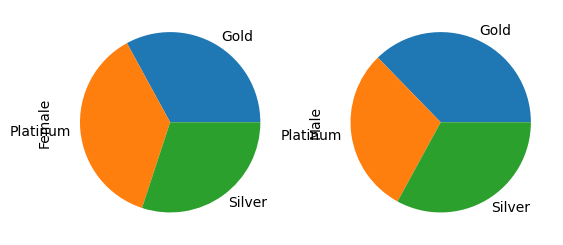

In [124]:
gender_segment_df_pivot.plot(kind='pie',subplots= True, legend= False)
plt.show()

# 12. Among males and females, which gender had claimed the most for any type of driver related issues? E.g. This metric can be compared using a bar chart

In [126]:
driver_claims_df = def_df[def_df['incident_cause'].str.contains('driver',case=False, na=False)]


In [127]:
gender_count_df= driver_claims_df.groupby(by= "gender")["gender"].count().reset_index(name= 'countof_gender')

In [128]:
gender_count_df

,gender,countof_gender
0,Female,221
1,Male,281


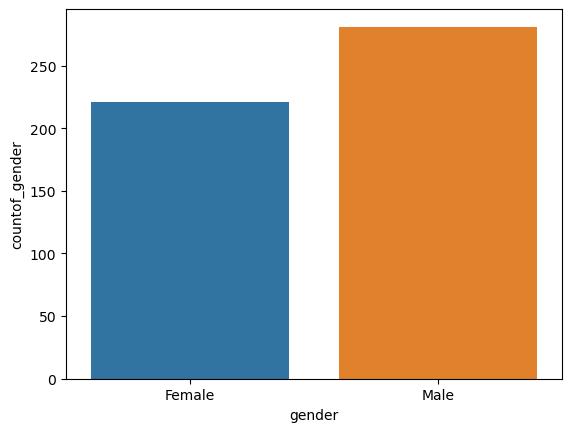

In [133]:
sns.barplot(y= "countof_gender", x = "gender" , data =gender_count_df , hue="gender")
plt.show()

# 13 Which age group had the maximum fraudulent policy claims? Visualize it on a bar chart.

In [136]:
Age_grp_fraud= def_df.groupby(by = 'Age_group')['fraudulent'].count().reset_index()

In [138]:
Age_grp_fraud

,Age_group,fraudulent
0,Adult,513
1,Children,247
2,Senior,7
3,Youth,318


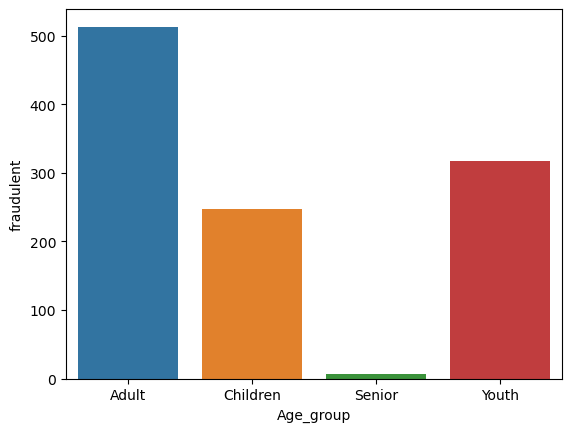

In [140]:
sns.barplot(x= "Age_group", y = "fraudulent" , data =Age_grp_fraud , hue="Age_group")
plt.show()

# 14. Visualize the monthly trend of the total amount that has been claimed by the customers. Ensure that on the “month” axis, the month is in a
chronological order not alphabetical order

In [143]:
def_df.columns

Index(['CUST_ID', 'gender', 'DateOfBirth', 'State', 'Contact', 'Segment',
       'claim_id', 'incident_cause', 'claim_date', 'claim_area', 'claim_type',
       'claim_amount', 'total_policy_claims', 'fraudulent', 'alert_flag',
       'age', 'Age_group'],
      dtype='object')

In [145]:
monthly_trend= def_df.groupby(['claim_date'])['claim_amount'].sum().reset_index()

In [147]:
monthly_trend

,claim_date,claim_amount
0,2017-01-01,203227.000000
1,2017-01-07,135383.500000
2,2017-01-14,138807.500000
3,2017-01-21,72638.953110
4,2017-01-27,57959.226555
...,...,...
95,2018-10-03,187868.726555
96,2018-10-09,225007.500000
97,2018-10-16,119829.000000
98,2018-10-23,147146.453110


In [149]:
# Extract the month name
monthly_trend['month_name'] = monthly_trend['claim_date'].dt.month_name()

In [151]:
monthly_claim = monthly_trend.groupby('month_name')['claim_amount'].sum().reset_index()
print(monthly_claim)


   month_name  claim_amount
0       April  1.292514e+06
1      August  9.112972e+05
2    December  6.942527e+05
3    February  1.164542e+06
4     January  1.327171e+06
5        July  1.379316e+06
6        June  1.279030e+06
7       March  1.320250e+06
8         May  1.114461e+06
9    November  6.011875e+05
10    October  1.409639e+06
11  September  9.832003e+05


In [153]:
# Group by 'month_name' and sum the 'claim_amount' for each month
monthly_claim = monthly_trend.groupby('month_name')['claim_amount'].sum().reindex(
    ['April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December','January', 'February', 'March']
).reset_index()

print(monthly_claim)


   month_name  claim_amount
0       April  1.292514e+06
1         May  1.114461e+06
2        June  1.279030e+06
3        July  1.379316e+06
4      August  9.112972e+05
5   September  9.832003e+05
6     October  1.409639e+06
7    November  6.011875e+05
8    December  6.942527e+05
9     January  1.327171e+06
10   February  1.164542e+06
11      March  1.320250e+06


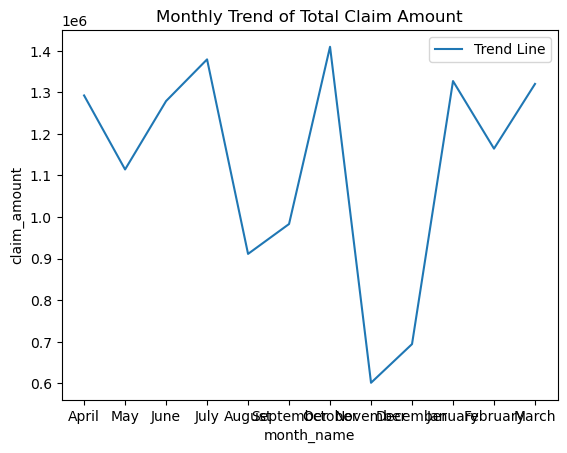

In [155]:
plt.plot(monthly_claim['month_name'],monthly_claim['claim_amount'],label='Trend Line')
plt.xlabel('month_name')
plt.ylabel('claim_amount')
plt.title('Monthly Trend of Total Claim Amount')
plt.legend()
plt.show()

# 15. What is the average claim amount for gender and age categories and suitably represent the above using a facetted bar chart, one facet that
represents fraudulent claims and the other for non-fraudulent claims.

In [158]:
 average_claim_amount = def_df.groupby(by = ["gender","Age_group","fraudulent"])["claim_amount"].mean().reset_index()

In [160]:
average_claim_amount

,gender,Age_group,fraudulent,claim_amount
0,Female,Adult,No,12404.086180
1,Female,Adult,Yes,16274.097442
2,Female,Children,No,12396.466730
3,Female,Children,Yes,6440.328571
4,Female,Senior,No,12501.726555
5,Female,Youth,No,12399.488606
6,Female,Youth,Yes,7760.340178
7,Male,Adult,No,12585.718036
8,Male,Adult,Yes,16752.358004
9,Male,Children,No,11734.134486


In [162]:
average_claim_amount_male = average_claim_amount.loc[average_claim_amount.gender == 'Male', ['claim_amount','Age_group','fraudulent']]

In [164]:
average_claim_amount_male

,claim_amount,Age_group,fraudulent
7,12585.718036,Adult,No
8,16752.358004,Adult,Yes
9,11734.134486,Children,No
10,16923.860000,Children,Yes
11,12501.726555,Senior,No
12,12381.804312,Youth,No
13,10686.017886,Youth,Yes


In [166]:
average_claim_amount_male_fraudulent = average_claim_amount_male.loc[average_claim_amount['fraudulent']=='Yes', ['claim_amount' , 'Age_group']]

In [168]:
average_claim_amount_male_fraudulent

,claim_amount,Age_group
8,16752.358004,Adult
10,16923.860000,Children
13,10686.017886,Youth


In [170]:
average_claim_amount_male_nonfraudulent =average_claim_amount_male.loc[average_claim_amount['fraudulent']=='No', ['claim_amount' , 'Age_group']]

In [172]:
average_claim_amount_male_nonfraudulent

,claim_amount,Age_group
7,12585.718036,Adult
9,11734.134486,Children
11,12501.726555,Senior
12,12381.804312,Youth


In [174]:
average_claim_amount_female = average_claim_amount.loc[average_claim_amount.gender == 'Female', ['claim_amount','Age_group','fraudulent']]

In [188]:
average_claim_amount_female

,claim_amount,Age_group,fraudulent
0,12404.086180,Adult,No
1,16274.097442,Adult,Yes
2,12396.466730,Children,No
3,6440.328571,Children,Yes
4,12501.726555,Senior,No
5,12399.488606,Youth,No
6,7760.340178,Youth,Yes


In [190]:
average_claim_amount_female_fraudulent = average_claim_amount_female.loc[average_claim_amount['fraudulent']=='Yes', ['claim_amount' , 'Age_group']]

In [192]:
average_claim_amount_female_fraudulent

,claim_amount,Age_group
1,16274.097442,Adult
3,6440.328571,Children
6,7760.340178,Youth


In [194]:
average_claim_amount_female_nonfraudulent =average_claim_amount_female.loc[average_claim_amount['fraudulent']=='No', ['claim_amount' , 'Age_group']]

In [196]:
average_claim_amount_female_nonfraudulent

,claim_amount,Age_group
0,12404.086180,Adult
2,12396.466730,Children
4,12501.726555,Senior
5,12399.488606,Youth


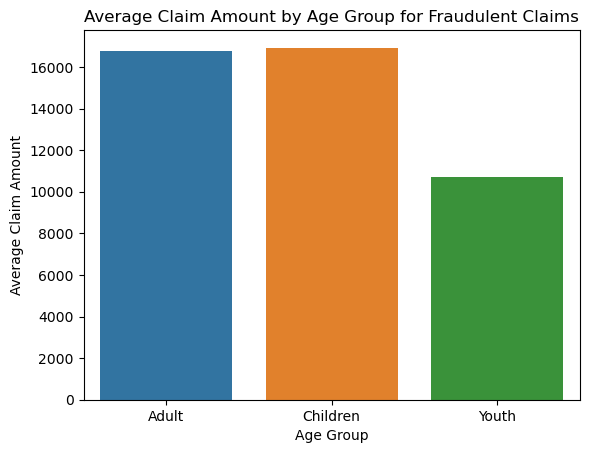

In [198]:
sns.barplot(x= "Age_group", y = "claim_amount" , data =average_claim_amount_male_fraudulent , hue="Age_group" )
plt.xlabel('Age Group')  # X-axis label
plt.ylabel('Average Claim Amount')  # Y-axis label

# Adding a title to the plot
plt.title('Average Claim Amount by Age Group for Fraudulent Claims')
plt.show()

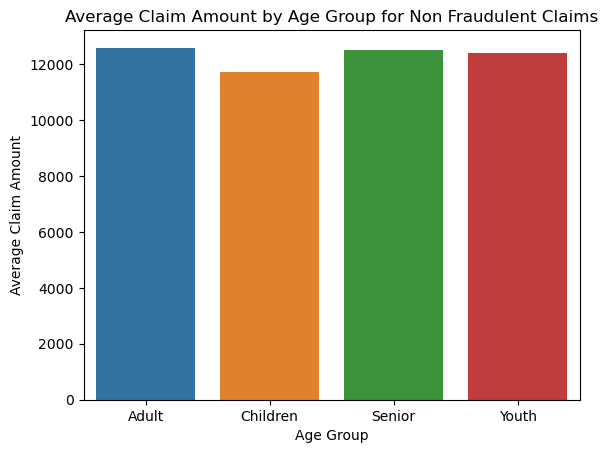

In [199]:
sns.barplot(x= "Age_group", y = "claim_amount" , data =average_claim_amount_male_nonfraudulent , hue="Age_group" )
plt.xlabel('Age Group')  # X-axis label
plt.ylabel('Average Claim Amount')  # Y-axis label

# Adding a title to the plot
plt.title('Average Claim Amount by Age Group for Non Fraudulent Claims')
plt.show()

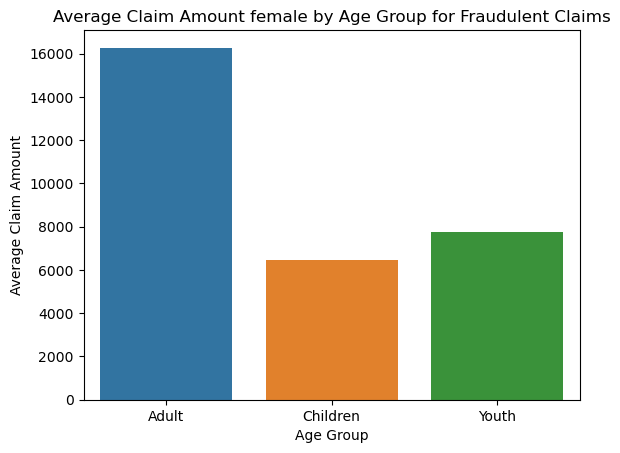

In [202]:
sns.barplot(x= "Age_group", y = "claim_amount" , data =average_claim_amount_female_fraudulent , hue="Age_group" )
plt.xlabel('Age Group')  # X-axis label
plt.ylabel('Average Claim Amount')  # Y-axis label

# Adding a title to the plot
plt.title('Average Claim Amount female by Age Group for Fraudulent Claims')
plt.show()

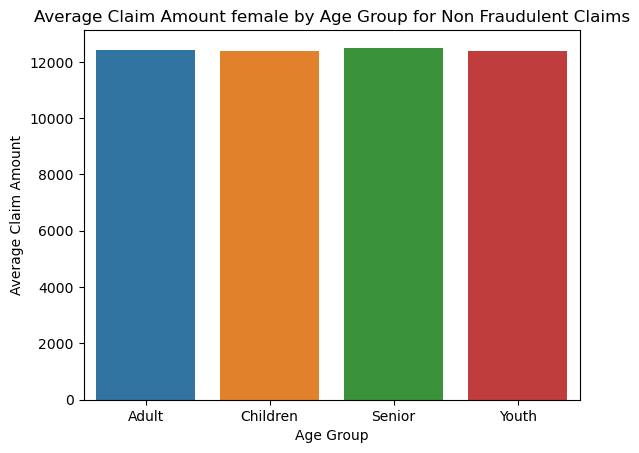

In [204]:
sns.barplot(x= "Age_group", y = "claim_amount" , data =average_claim_amount_female_nonfraudulent , hue="Age_group" )
plt.xlabel('Age Group')  # X-axis label
plt.ylabel('Average Claim Amount')  # Y-axis label

# Adding a title to the plot
plt.title('Average Claim Amount female by Age Group for Non Fraudulent Claims')
plt.show()

Based on the conclusions from exploratory analysis as well as suitable statistical tests, answer the below questions. Please include a detailed write-up on the parameters taken into consideration, the Hypothesis testing steps, conclusion from the p-values and the business implications of
the statements.
16. Is there any similarity in the amount claimed by males and females?

In [206]:
# Ho = no relationship
# Ha = relationship for the amount claimed by males and females

#CI = 97%       p/alpha =0.03

In [207]:
males = def_df[def_df['gender'] == 'Male']['claim_amount']
females = def_df[def_df['gender'] == 'Female']['claim_amount']


In [211]:
print(males.mean())
print(females.mean())

12883.459510093915
12104.925193351099


In [213]:
t_stat, p_value = stats.ttest_ind(males, females)

In [215]:
t_stat, p_value

(0.9624541122991915, 0.3360363827572097)

In [217]:
# conclusion = p_value > 0.03. Hence we accept Null Hypothesis Ho and there is no relatipnship for amount claimed by males and females.          

# 17. Is there any relationship between age category and segment?

In [220]:
# Ho = no relationship
# Ha = relationship between age category and segment

#CI = 97%       p/alpha =0.03

In [222]:
# get the ob_freq_table from the dataset
obs_freq = pd.crosstab(def_df.Segment, def_df.Age_group)
obs_freq

Age_group,Adult,Children,Senior,Youth
Segment,,,,
Gold,187,82,1,102
Platinum,161,84,3,116
Silver,165,81,3,100


In [224]:
stats.chi2_contingency(obs_freq)

Chi2ContingencyResult(statistic=4.113627587049837, pvalue=0.6613026721544895, dof=6, expected_freq=array([[175.88571429,  84.68571429,   2.4       , 109.02857143],
       [172.10322581,  82.86451613,   2.3483871 , 106.68387097],
       [165.01105991,  79.44976959,   2.2516129 , 102.2875576 ]]))

In [226]:
# conclusion:  p_value > 0.003. Hence we accept Null Hypothesis Ho and there is no relatipnship between age category and segment.

# 18 The current year has shown a significant rise in claim amounts as compared to 2016-17 fiscal average which was $10,000.

In [229]:
# Ho , fiscal average = 10000
# Ha ,fiscal average > 10000

#CI = 97%       p/alpha =0.03
fiscal_avg = 10000

In [231]:
def_df.columns

Index(['CUST_ID', 'gender', 'DateOfBirth', 'State', 'Contact', 'Segment',
       'claim_id', 'incident_cause', 'claim_date', 'claim_area', 'claim_type',
       'claim_amount', 'total_policy_claims', 'fraudulent', 'alert_flag',
       'age', 'Age_group'],
      dtype='object')

In [233]:
def_df_new = def_df.groupby(['claim_date'])['claim_amount'].sum().reset_index()

In [235]:
def_df_new 

,claim_date,claim_amount
0,2017-01-01,203227.000000
1,2017-01-07,135383.500000
2,2017-01-14,138807.500000
3,2017-01-21,72638.953110
4,2017-01-27,57959.226555
...,...,...
95,2018-10-03,187868.726555
96,2018-10-09,225007.500000
97,2018-10-16,119829.000000
98,2018-10-23,147146.453110


In [237]:
def_df_new['year'] = pd.to_datetime(def_df_new['claim_date']).dt.year 

In [239]:
def_df_new['year']

0     2017
1     2017
2     2017
3     2017
4     2017
      ... 
95    2018
96    2018
97    2018
98    2018
99    2018
Name: year, Length: 100, dtype: int32

In [241]:
year_claims_2017 = def_df_new[def_df_new['year'] == 2017]['claim_amount'].mean()

In [243]:
year_claims_2017 

132659.89133088037

In [245]:
year_claims_2018 = def_df_new[def_df_new['year'] == 2018]['claim_amount']

In [247]:
year_claims_2018

55    200633.000000
56    243699.226555
57    165055.179664
58    109767.000000
59    111798.500000
60    141549.726555
61    136554.226555
62    143183.500000
63    158908.726555
64    131597.000000
65    173169.726555
66    166746.500000
67     74251.726555
68    167163.000000
69    117591.726555
70    114531.000000
71    145252.500000
72     43363.500000
73    139703.453110
74    148733.226555
75    180405.000000
76     55514.453110
77     97404.000000
78    104810.000000
79    158834.000000
80    203985.679664
81    153852.953110
82    134579.000000
83     78088.726555
84    220816.179664
85    154963.226555
86     28033.000000
87    212442.726555
88    147459.500000
89     28217.000000
90     63528.500000
91    198984.226555
92     87230.000000
93    153193.226555
94     84323.726555
95    187868.726555
96    225007.500000
97    119829.000000
98    147146.453110
99    120797.953110
Name: claim_amount, dtype: float64

In [249]:
stats.ttest_1samp(year_claims_2018, fiscal_avg )

TtestResult(statistic=16.529629598301664, pvalue=1.7156447889282593e-20, df=44)

In [251]:
print(year_claims_2018.head())  # Display the first few row

55    200633.000000
56    243699.226555
57    165055.179664
58    109767.000000
59    111798.500000
Name: claim_amount, dtype: float64


In [253]:
print(type(year_claims_2018))

<class 'pandas.core.series.Series'>


In [255]:
year_claims_2018.isnull().sum()

0

In [257]:
a= year_claims_2018.mean()

In [259]:
stats.ttest_1samp(a, fiscal_avg )

D:\python\Lib\site-packages\scipy\stats\_stats_py.py:1087: RuntimeWarning: divide by zero encountered in divide
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
D:\python\Lib\site-packages\scipy\stats\_stats_py.py:1087: RuntimeWarning: invalid value encountered in scalar multiply
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero


TtestResult(statistic=nan, pvalue=nan, df=0)

# 19. Is there any difference between age groups and insurance claims?

In [262]:
# Ho = no difference between age groups and insurance claims
# Ha = difference between age groups and insurance claims

#CI = 97%       p/alpha =0.03

In [264]:
def_df.Age_group.nunique()

4

In [266]:
def_df.Age_group.value_counts()

Age_group
Adult       513
Youth       318
Children    247
Senior        7
Name: count, dtype: int64

In [268]:
def_df.columns

Index(['CUST_ID', 'gender', 'DateOfBirth', 'State', 'Contact', 'Segment',
       'claim_id', 'incident_cause', 'claim_date', 'claim_area', 'claim_type',
       'claim_amount', 'total_policy_claims', 'fraudulent', 'alert_flag',
       'age', 'Age_group'],
      dtype='object')

In [270]:
s1= def_df.loc[def_df.Age_group=='Adult','claim_amount']

In [272]:
s2 = def_df.loc[def_df.Age_group=='Youth','claim_amount']

In [274]:
s3 = def_df.loc[def_df.Age_group=='Children','claim_amount']

In [276]:
s4 =  def_df.loc[def_df.Age_group=='Senior','claim_amount']

In [278]:
print( 'mean of s1: ', s1.mean(), '| mean of s2: ', s2.mean() , '| mean of s3: ', s3.mean() , '| mean of s4:', s4.mean() )

mean of s1:  13375.785087238224 | mean of s2:  11677.184772485984 | mean of s3:  11747.930035050418 | mean of s4: 12501.72655478776


In [280]:
stats.f_oneway(s1,s2,s3,s4)

F_onewayResult(statistic=1.4078888841982677, pvalue=0.23892705474526085)

In [282]:
#  conclusion : pvalue > 0.03. hence we accept null hypothesis Ho and  no difference between age groups and insurance claims

# 20.Is there any relationship between total number of policy claims and the claimed amount?

In [285]:
# Ho = no relationship between total number of policy claims and the claimed amount
# Ha = relationship between total number of policy claims and the claimed amount

#CI = 97%       p/alpha =0.03

In [287]:
def_df.columns

Index(['CUST_ID', 'gender', 'DateOfBirth', 'State', 'Contact', 'Segment',
       'claim_id', 'incident_cause', 'claim_date', 'claim_area', 'claim_type',
       'claim_amount', 'total_policy_claims', 'fraudulent', 'alert_flag',
       'age', 'Age_group'],
      dtype='object')

In [289]:
def_df.total_policy_claims.value_counts()

total_policy_claims
1.0    779
2.0    105
3.0     85
4.0     59
5.0     27
6.0     10
7.0      2
8.0      1
Name: count, dtype: int64

In [291]:
s_1= def_df.loc[def_df.total_policy_claims==1.0,'claim_amount']

In [293]:
s_2= def_df.loc[def_df.total_policy_claims==2.0,'claim_amount']

In [295]:
s_3= def_df.loc[def_df.total_policy_claims==3.0,'claim_amount']

In [297]:
s_4= def_df.loc[def_df.total_policy_claims==4.0,'claim_amount']

In [299]:
s_5= def_df.loc[def_df.total_policy_claims==5.0,'claim_amount']

In [301]:
s_6= def_df.loc[def_df.total_policy_claims==6.0,'claim_amount']

In [303]:
s_7= def_df.loc[def_df.total_policy_claims==7.0,'claim_amount']

In [305]:
s_8= def_df.loc[def_df.total_policy_claims==8.0,'claim_amount']

In [307]:
print( 'mean of s_1: ', s_1.mean(), '| mean of s_2: ', s_2.mean() , '| mean of s_3: ', s_3.mean() , '| mean of s_4:', s_4.mean() ,'| mean of s_5: ', s_5.mean(), '| mean of s_6: ', s_6.mean() , '| mean of s_7: ', s_7.mean() , '| mean of s_8:', s_8.mean())

mean of s_1:  12503.33966775944 | mean of s_2:  13766.818154468103 | mean of s_3:  12631.827756808547 | mean of s_4: 11108.075476433483 | mean of s_5:  8532.77604109539 | mean of s_6:  14290.172655478778 | mean of s_7:  23033.0 | mean of s_8: 3277.5


In [309]:
stats.f_oneway(s_1,s_2,s_3,s_4,s_5,s_6,s_7,s_8)

F_onewayResult(statistic=0.8389305140384531, pvalue=0.5549962679331616)

In [311]:
# conclusion : pvalue > 0.03. hence we accept null hypothesis Ho and  no  relationship between total number of policy claims and the claimed amount